# FUSOU: Game Mechanics Analysis Pipeline (Jupyter Notebook Demo)

このNotebookでは、FUSOUデータベースのトランザクションから「隠れ変数（弾薬ペナルティなど）」を含む**ゲームのダメージ計算式を自動でリバースエンジニアリング**する手順をステップ・バイ・ステップで体験できます。

パイプラインの最終目標は、ノイズだらけのデータから**「各フェーズ・キャップ値ごとの数式（Formula）」を導き出して表示すること**です。


In [1]:
import sys
import os
import matplotlib.pyplot as plt

# グラフをNotebook上にインライン表示させるためのおまじない
%matplotlib inline

# パッケージ上位のモジュールを読み込めるようにパスを追加
sys.path.insert(0, os.path.abspath('../..'))

from analysis.analyzer import GameMechanicsAnalyzer
from analysis.data_loader import generate_synthetic_data
import pandas as pd


## 1. データの準備（合成データの生成）
ここではFUSOU本番DBの代わりとして、「火力キャップ（180）と平方根、クリティカル倍率」を含み、さらに「16個の無関係なダミー変数」を混ぜ込んだ合成データセットを生成します。


In [2]:
# ダミーデータの生成スクリプト
import numpy as np

n = 3000
rng = np.random.default_rng(42)

karyoku = rng.integers(30, 250, size=n)
soukou = rng.integers(40, 120, size=n)
ammo_mod = rng.uniform(0.7, 1.0, size=n)
phases = ["day_shelling", "night_battle", "opening_torpedo"]
phase = rng.choice(phases, size=n)

base_atk = karyoku * 1.5
base_atk[phase == "night_battle"] *= 1.2

damage = np.maximum(0, (base_atk - soukou) * ammo_mod)
damage = np.floor(damage).astype(int)

data = {
    "attacker_karyoku": karyoku,
    "defender_soukou": soukou,
    "ammo_modifier": ammo_mod,
    "battle_phase": phase,
    "damage": damage,
}

for i in range(1, 15):
    data[f"noise_stat_{i}"] = rng.integers(0, 100, size=n)

df = pd.DataFrame(data)
candidate_cols = [c for c in df.columns if c != "damage"]

df.head()


,attacker_karyoku,defender_soukou,ammo_modifier,battle_phase,damage,noise_stat_1,noise_stat_2,noise_stat_3,noise_stat_4,noise_stat_5,noise_stat_6,noise_stat_7,noise_stat_8,noise_stat_9,noise_stat_10,noise_stat_11,noise_stat_12,noise_stat_13,noise_stat_14
0,49,102,0.948766,night_battle,0,7,72,18,92,91,23,36,50,64,37,81,18,69,54
1,200,93,0.878229,night_battle,234,50,87,36,51,82,34,84,13,91,36,53,77,98,52
2,174,114,0.773456,day_shelling,113,56,14,70,61,61,86,70,35,11,98,80,33,66,40
3,126,116,0.923703,day_shelling,67,73,24,5,35,30,10,17,79,7,73,20,53,84,36
4,125,96,0.725344,night_battle,93,57,3,91,89,65,10,99,60,66,85,26,90,31,24


## 2. 解析の実行（Feature Selection 〜 Formula Discovery）
`GameMechanicsAnalyzer` に全ての候補カラム（`x_cols`）を渡し、`auto_select_features=True` で解析を走らせます。

数式の導出自体は Stage 3 の `FormulaDiscoverer`（内部的にはPySRやscikit-learn線形回帰）が行います。


In [3]:
analyzer = GameMechanicsAnalyzer(min_samples=2)

print("解析をスタートします...数秒お待ちください。\n")

result = analyzer.fit_and_discover(
    df,
    x_cols=candidate_cols,
    y_col="damage",
    auto_select_features=True,
    num_features=4,
)


解析をスタートします...数秒お待ちください。

=== Stage 0: Feature Selector ===
  Selecting top 4 features from 18 candidates ...


  -> Selected features: ['attacker_karyoku', 'defender_soukou', 'ammo_modifier', 'battle_phase']

  One-hot encoding categorical variables: ['battle_phase']
  -> Updated predictors: ['attacker_karyoku', 'defender_soukou', 'ammo_modifier', 'battle_phase_night_battle', 'battle_phase_opening_torpedo']

=== Stage 1: NoiseFilter ===
  Predictor(s) (X): ['attacker_karyoku', 'defender_soukou', 'ammo_modifier', 'battle_phase_night_battle', 'battle_phase_opening_torpedo']
    Primary variable for cap detection: attacker_karyoku
    Additional variables for formula: ['defender_soukou', 'ammo_modifier', 'battle_phase_night_battle', 'battle_phase_opening_torpedo']
  Target (Y): damage
  Extracting 99% / 1% percentiles ...
  -> 220 unique X-groups after filtering.

=== Stage 2: CapDetector ===
  Detecting slope changes in Y_max(attacker_karyoku) ...
  Method: gradient
  -> Caps detected at attacker_karyoku = [166, 187, 210, 234]
  -> 5 segment(s).

=== Stage 3: FormulaDiscoverer ===
  Using 5 input

C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr')

## 3. 【結果】得られた数式の確認！
得られた数式は `analyzer.summary()` や、`result.formula_results` オブジェクトの中に格納されています。
これを出力することで、**各セグメント（キャップ）ごとに逆算された具体的な数式**を確認できます！


In [4]:
# 得られた解析サマリー（数式を含む）をテキストで出力
print(analyzer.summary())

# 個別の数式だけをプログラムから抜き出す場合
print("================= 単独の数式オブジェクト =================")
for formula in result.formula_results:
    print(f"[Segment {formula.segment_index}]")
    print(f"  推論式: {formula.equation}")
    print(f"  誤差(MAE): {formula.mae:.2f}\n")


+==================================================+
|       Game Mechanics Analysis Summary             |
+==================================================+

---- Stage 0: Feature Selection ----------------------------
  Method:      random_forest
  Selected:    ['attacker_karyoku', 'defender_soukou', 'ammo_modifier', 'battle_phase']
  Scores:
    - attacker_karyoku: 1.0000
    - defender_soukou: 0.0408
    - ammo_modifier: 0.0339
    - battle_phase: 0.0215

  Predictor(s) (X): ['attacker_karyoku', 'defender_soukou', 'ammo_modifier', 'battle_phase_night_battle', 'battle_phase_opening_torpedo']
    Primary var:    attacker_karyoku
  Target       (Y): damage
  X Range (attacker_karyoku): [30, 249]
  Unique X groups:  220

---- Cap Detection -----------------------------------------
  Method:     gradient
  Caps found: 4
  Thresholds: [166, 187, 210, 234]
  Segments:   5

---- Discovered Formulas -----------------------------------
  Segment 0: attacker_karyoku in [30, 165]
    Inputs:

## 4. 可視化（グラフの表示）
データノイズの絞り込み、キャップの検知点、そして導出された数式と実データのズレ（残差）をプロットします。


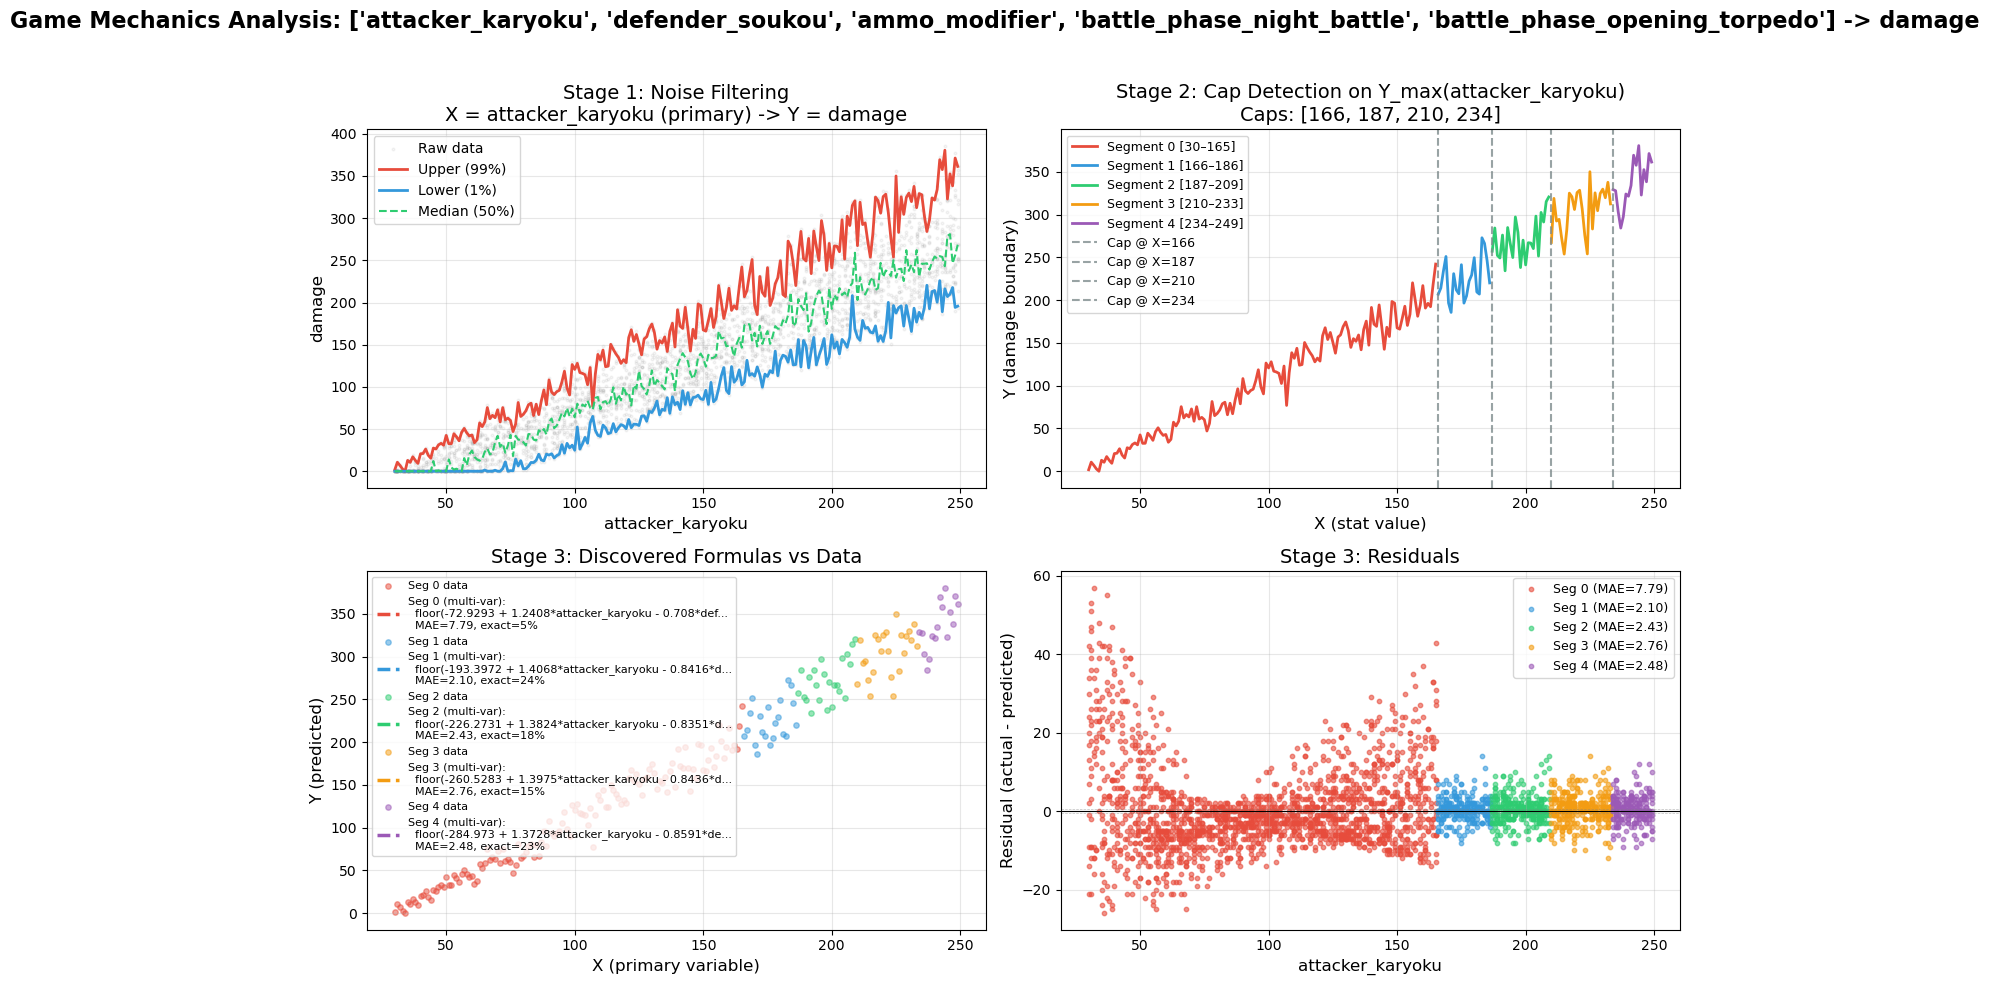

In [5]:
# プロットの表示（Notebook上にインラインでレンダリングされます）
analyzer.plot_results(figsize=(14, 10))
